# MCBoE Registration-Status Clustering

This notebook validates the three provided datasets, isolates the mandated **registration status / voter-record confusion** readiness focus, cleans detailed service labels conservatively, builds a category-level feature matrix, and tests K-means clustering.

Each section contains checks so that structural problems fail early instead of silently affecting later results.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def check(condition, message):
    if not condition:
        raise AssertionError(message)
    print("PASS:", message)

def find_file(name):
    candidates = [Path.cwd() / name, Path("/mnt/data") / name]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"{name} was not found in the notebook folder or /mnt/data.")

## 1. Load and validate the datasets

In [2]:
requests_path = find_file("filtered_election_requests.xlsx")
dictionary_path = find_file("request_topic_dictionary_all_audit.csv")
zip_path = find_file("zip_codes.csv")

requests = pd.read_excel(requests_path)
dictionary = pd.read_csv(dictionary_path)
zips = pd.read_csv(zip_path)

required_request_cols = {
    "SR ID", "Opened", "Source", "Request Type",
    "service", "topic", "readiness_focus"
}
required_dictionary_cols = {"service_category", "topic", "readiness_focus"}
required_zip_cols = {"zip_code", "population", "median_household_income", "households"}

check(len(requests) > 0, "Election-request dataset loaded.")
check(required_request_cols.issubset(requests.columns), "Election-request columns are present.")
check(required_dictionary_cols.issubset(dictionary.columns), "Dictionary columns are present.")
check(required_zip_cols.issubset(zips.columns), "ZIP-code columns are present.")

print("Requests:", requests.shape)
print("Dictionary:", dictionary.shape)
print("ZIP data:", zips.shape)

PASS: Election-request dataset loaded.
PASS: Election-request columns are present.
PASS: Dictionary columns are present.
PASS: ZIP-code columns are present.
Requests: (11654, 28)
Dictionary: (276, 3)
ZIP data: (65, 5)


## 2. Isolate the mandated readiness focus

In [3]:
reg = requests.loc[requests["readiness_focus"].eq("registration_status")].copy()

check(len(reg) > 0, "Registration-status records were found.")
check(reg["readiness_focus"].nunique() == 1, "Only the mandated readiness focus is included.")
check(reg["topic"].notna().all(), "All registration records have a broader topic.")
check(reg["service"].notna().all(), "All registration records have a detailed service category.")

print("Registration requests:", len(reg))
print("Broader topics:", reg["topic"].nunique())
print("Detailed service categories:", reg["service"].nunique())
display(reg["topic"].value_counts().rename("requests").to_frame())

PASS: Registration-status records were found.
PASS: Only the mandated readiness focus is included.
PASS: All registration records have a broader topic.
PASS: All registration records have a detailed service category.
Registration requests: 2752
Broader topics: 9
Detailed service categories: 61


,requests
topic,
General voter registration questions,718
Registration verification,579
Registering to vote,458
Address or name change,382
Eligibility/residency/re-registration,179
Voter notification card,152
Record maintenance,110
Party affiliation,97
Registration deadline,77


## 3. Confirm the provided topic dictionary matches the request data

In [4]:
audit = reg.merge(
    dictionary,
    left_on="service",
    right_on="service_category",
    how="left",
    suffixes=("_request", "_dictionary")
)

check(audit["service_category"].notna().all(), "Every registration service appears in the supplied dictionary.")
check((audit["topic_request"] == audit["topic_dictionary"]).all(), "Broader topics match the supplied dictionary.")
check(
    (audit["readiness_focus_request"] == audit["readiness_focus_dictionary"]).all(),
    "Readiness-focus labels match the supplied dictionary."
)

PASS: Every registration service appears in the supplied dictionary.
PASS: Broader topics match the supplied dictionary.
PASS: Readiness-focus labels match the supplied dictionary.


## 4. Basic cleaning and data-quality checks

In [5]:
reg["Opened_dt"] = pd.to_datetime(reg["Opened"], errors="coerce")

check(reg["SR ID"].notna().all(), "All registration records have an SR ID.")
check(reg["SR ID"].duplicated().sum() == 0, "No duplicate SR IDs are present in the registration subset.")
check(reg["Opened_dt"].notna().all(), "All opened dates parsed successfully.")
check(reg["Source"].notna().all(), "All registration records have a request source.")
check(reg["Request Type"].notna().all(), "All registration records have a request type.")

print("Year range:", reg["Opened_dt"].dt.year.min(), "to", reg["Opened_dt"].dt.year.max())
print("\nSource distribution:")
display(reg["Source"].value_counts().rename("requests").to_frame())
print("\nRequest-type distribution:")
display(reg["Request Type"].value_counts().rename("requests").to_frame())
print("\nMissing ZIP codes:", reg["Zip Code"].isna().sum(), "of", len(reg))

PASS: All registration records have an SR ID.
PASS: No duplicate SR IDs are present in the registration subset.
PASS: All opened dates parsed successfully.
PASS: All registration records have a request source.
PASS: All registration records have a request type.
Year range: 2012 to 2026

Source distribution:


,requests
Source,
Phone,2618
Web,116
Internal,15
Walk In,3



Request-type distribution:


,requests
Request Type,
General Information,2551
Service Request - Fulfillment,195
Referral,6



Missing ZIP codes: 2328 of 2752


## 5. Audit detailed service categories

The original detailed categories are preserved. Cleaning below removes only repeated administrative prefixes and request-disposition suffixes. It does **not** change the mandated broader topic.

In [6]:
raw_service_counts = reg["service"].value_counts()

print("Raw detailed service categories:", len(raw_service_counts))
display(raw_service_counts.rename("requests").to_frame().head(20))

Raw detailed service categories: 61


,requests
service,
voter registration registrations verification of voter registration general information,545
voter registration general register to vote general information,426
voter registration registrations maryland and local elected representatives general information,402
voter registration registrations updating voter registration information general information,192
voter registration registrations find montgomery county resident's legislative district and elected representatives general information,148
"voter registration registrations voter notification card, voter notification replacement general information",98
voter registration general voter registration - residency requirements general information,97
voter registration registrations political party affiliation general information,95
"voter registration registrations updating voter registration information (name, address, party affiliation) general information",89


In [7]:
def clean_service_label(value):
    s = str(value).strip().lower()

    suffixes = [
        " service request - fulfillment",
        " general information",
        " referral"
    ]
    for suffix in suffixes:
        if s.endswith(suffix):
            s = s[:-len(suffix)]

    prefixes = [
        "voter registration registrations ",
        "voter registration operations ",
        "voter registration general ",
        "voter registration  ",
        "voter registration ",
        "other  "
    ]
    for prefix in prefixes:
        if s.startswith(prefix):
            s = s[len(prefix):]
            break

    s = re.sub(r"^[-: ]+", "", s)
    return " ".join(s.split())

reg["service_clean"] = reg["service"].map(clean_service_label)

check(reg["service_clean"].notna().all(), "All detailed service labels were cleaned.")
check((reg["service_clean"].str.len() > 0).all(), "No cleaned service label is blank.")
check(
    reg.groupby("service_clean")["topic"].nunique().max() == 1,
    "Cleaning did not merge categories from different mandated broader topics."
)

print("Raw service categories:", reg["service"].nunique())
print("Cleaned service categories:", reg["service_clean"].nunique())
display(reg["service_clean"].value_counts().rename("requests").to_frame().head(20))

PASS: All detailed service labels were cleaned.
PASS: No cleaned service label is blank.
PASS: Cleaning did not merge categories from different mandated broader topics.
Raw service categories: 61
Cleaned service categories: 41


,requests
service_clean,
verification of voter registration,555
register to vote,435
maryland and local elected representatives,404
updating voter registration information,245
find montgomery county resident's legislative district and elected representatives,148
"voter notification card, voter notification replacement",141
"updating voter registration information (name, address, party affiliation)",119
voter registration - residency requirements,97
political party affiliation,97


## 6. Build the category-level feature matrix

Each row below is one cleaned detailed service category. The clustering features describe how that category appears in MC311: request volume, source mix, and request-type mix.

The mandated broader topic is retained only for later interpretation.

In [8]:
category = (
    reg.groupby("service_clean")
       .agg(
           n_requests=("SR ID", "size"),
           topic=("topic", "first")
       )
       .reset_index()
)

source_levels = ["Phone", "Web", "Internal", "Walk In"]
request_levels = ["General Information", "Service Request - Fulfillment", "Referral"]

for level in source_levels:
    share = (
        reg.assign(flag=reg["Source"].eq(level).astype(int))
           .groupby("service_clean")["flag"]
           .mean()
    )
    category[f"pct_source_{level.lower().replace(' ', '_')}"] = category["service_clean"].map(share)

for level in request_levels:
    share = (
        reg.assign(flag=reg["Request Type"].eq(level).astype(int))
           .groupby("service_clean")["flag"]
           .mean()
    )
    name = level.lower().replace(" ", "_").replace("-", "")
    category[f"pct_type_{name}"] = category["service_clean"].map(share)

category["log_requests"] = np.log1p(category["n_requests"])

check(len(category) == reg["service_clean"].nunique(), "Feature matrix has one row per cleaned service category.")
check(category.isna().sum().sum() == 0, "Feature matrix contains no missing values.")
check((category["n_requests"] > 0).all(), "Every category has at least one request.")

source_cols = [c for c in category.columns if c.startswith("pct_source_")]
type_cols = [c for c in category.columns if c.startswith("pct_type_")]

check(
    np.allclose(category[source_cols].sum(axis=1), 1),
    "Source shares sum to 1 for every category."
)
check(
    np.allclose(category[type_cols].sum(axis=1), 1),
    "Request-type shares sum to 1 for every category."
)

display(category.sort_values("n_requests", ascending=False).head(15))

PASS: Feature matrix has one row per cleaned service category.
PASS: Feature matrix contains no missing values.
PASS: Every category has at least one request.
PASS: Source shares sum to 1 for every category.
PASS: Request-type shares sum to 1 for every category.


,service_clean,n_requests,topic,pct_source_phone,pct_source_web,pct_source_internal,pct_source_walk_in,pct_type_general_information,pct_type_service_request__fulfillment,pct_type_referral,log_requests
32,verification of voter registration,555,Registration verification,0.987387,0.005405,0.005405,0.001802,0.981982,0.010811,0.007207,6.320768
24,register to vote,435,Registering to vote,0.993103,0.002299,0.004598,0.000000,0.979310,0.020690,0.000000,6.077642
15,maryland and local elected representatives,404,General voter registration questions,0.990099,0.000000,0.009901,0.000000,0.995050,0.002475,0.002475,6.003887
30,updating voter registration information,245,Address or name change,0.865306,0.122449,0.012245,0.000000,0.783673,0.216327,0.000000,5.505332
10,find montgomery county resident's legislative ...,148,General voter registration questions,0.993243,0.000000,0.006757,0.000000,1.000000,0.000000,0.000000,5.003946
33,"voter notification card, voter notification re...",141,Voter notification card,0.815603,0.184397,0.000000,0.000000,0.695035,0.304965,0.000000,4.955827
31,"updating voter registration information (name,...",119,Address or name change,0.823529,0.176471,0.000000,0.000000,0.747899,0.252101,0.000000,4.787492
20,political party affiliation,97,Party affiliation,0.989691,0.010309,0.000000,0.000000,0.979381,0.020619,0.000000,4.584967
34,voter registration - residency requirements,97,Eligibility/residency/re-registration,0.989691,0.000000,0.010309,0.000000,1.000000,0.000000,0.000000,4.584967
39,voting eligibilty for prospective voter that m...,61,Eligibility/residency/re-registration,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.127134


## 7. Prepare clustering features

Time-to-resolution and SLA measures are intentionally excluded. Timing can be examined descriptively later, but it is not used here as a performance measure.

In [9]:
features = [
    "log_requests",
    "pct_source_phone",
    "pct_source_web",
    "pct_source_internal",
    "pct_source_walk_in",
    "pct_type_general_information",
    "pct_type_service_request__fulfillment",
    "pct_type_referral"
]

check(set(features).issubset(category.columns), "All planned clustering features exist.")

scaler = StandardScaler()
X = scaler.fit_transform(category[features])

check(X.shape == (len(category), len(features)), "Scaled feature matrix has the expected shape.")
check(np.isfinite(X).all(), "Scaled feature matrix contains only finite values.")

print("Feature matrix shape:", X.shape)

PASS: All planned clustering features exist.
PASS: Scaled feature matrix has the expected shape.
PASS: Scaled feature matrix contains only finite values.
Feature matrix shape: (41, 8)


## 8. Compare possible values of k

In [10]:
results = []

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X)

    check(len(labels) == len(category), f"k={k}: every category received a cluster label.")
    check(len(np.unique(labels)) == k, f"k={k}: all requested clusters were created.")

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
        "smallest_cluster": pd.Series(labels).value_counts().min()
    })

k_results = pd.DataFrame(results)
display(k_results)

PASS: k=2: every category received a cluster label.
PASS: k=2: all requested clusters were created.
PASS: k=3: every category received a cluster label.
PASS: k=3: all requested clusters were created.
PASS: k=4: every category received a cluster label.
PASS: k=4: all requested clusters were created.
PASS: k=5: every category received a cluster label.
PASS: k=5: all requested clusters were created.
PASS: k=6: every category received a cluster label.
PASS: k=6: all requested clusters were created.


,k,inertia,silhouette,smallest_cluster
0,2,224.213708,0.455414,6
1,3,182.170498,0.373323,6
2,4,141.902195,0.371427,1
3,5,101.875460,0.438202,1
4,6,67.268972,0.470743,1


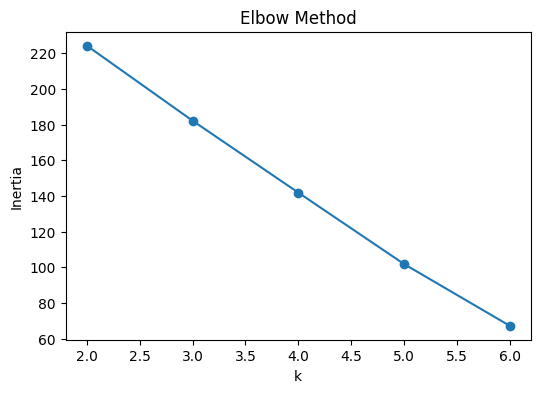

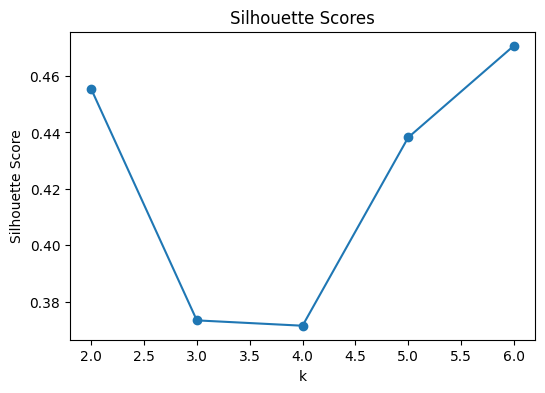

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")
plt.show()

## 9. Create a provisional clustering result

This notebook does **not** assume the final k in advance. For a first structural check, it uses the k with the highest silhouette score, then reports cluster sizes and category composition. The final project can override this choice if another k is more interpretable and still statistically reasonable.

In [12]:
best_k = int(k_results.loc[k_results["silhouette"].idxmax(), "k"])

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=20)
category["cluster"] = final_model.fit_predict(X)

check(category["cluster"].notna().all(), "Every category has a provisional cluster.")
check(category["cluster"].nunique() == best_k, "The provisional model produced the selected number of clusters.")

print("Provisional k:", best_k)
display(category["cluster"].value_counts().sort_index().rename("categories").to_frame())

PASS: Every category has a provisional cluster.
PASS: The provisional model produced the selected number of clusters.
Provisional k: 6


,categories
cluster,
0,19
1,2
2,2
3,7
4,1
5,10


In [13]:
cluster_summary = (
    category.groupby("cluster")
            .agg(
                categories=("service_clean", "size"),
                total_requests=("n_requests", "sum"),
                median_category_requests=("n_requests", "median"),
                mean_phone_share=("pct_source_phone", "mean"),
                mean_web_share=("pct_source_web", "mean"),
                mean_general_info_share=("pct_type_general_information", "mean"),
                mean_fulfillment_share=("pct_type_service_request__fulfillment", "mean")
            )
            .round(3)
)

check(cluster_summary["categories"].sum() == len(category), "Cluster summary accounts for every cleaned service category.")
check(cluster_summary["total_requests"].sum() == len(reg), "Cluster summary accounts for every registration request.")

display(cluster_summary)

PASS: Cluster summary accounts for every cleaned service category.
PASS: Cluster summary accounts for every registration request.


,categories,total_requests,median_category_requests,mean_phone_share,mean_web_share,mean_general_info_share,mean_fulfillment_share
cluster,,,,,,,
0,19,404,11.0,0.999,0.001,0.997,0.003
1,2,20,10.0,0.158,0.842,0.158,0.842
2,2,56,28.0,0.964,0.000,1.000,0.000
3,7,1917,245.0,0.970,0.019,0.963,0.036
4,1,22,22.0,1.000,0.000,0.773,0.182
5,10,333,11.0,0.841,0.159,0.557,0.443


In [14]:
for cluster_id in sorted(category["cluster"].unique()):
    print(f"\nCluster {cluster_id}")
    display(
        category.loc[category["cluster"].eq(cluster_id),
                     ["service_clean", "topic", "n_requests"]]
                .sort_values("n_requests", ascending=False)
                .head(12)
    )


Cluster 0


,service_clean,topic,n_requests
20,political party affiliation,Party affiliation,97
39,voting eligibilty for prospective voter that m...,Eligibility/residency/re-registration,61
35,voter registration and voter registration dead...,Registration deadline,52
0,board of elections (boe) notice received by ma...,Record maintenance,48
13,mail from state reporting inability to verify ...,Registration verification,24
25,register to vote deadline,Registration deadline,23
18,name change deadline for voter eligibility in ...,Address or name change,18
17,municipality elections,General voter registration questions,17
2,board of elections 2014 gubernatorial primary,General voter registration questions,16
8,election results for 2018 primary and for past...,General voter registration questions,11



Cluster 1


,service_clean,topic,n_requests
28,removal of deceased family member from voting ...,Record maintenance,19
4,board of elections compliments,General voter registration questions,1



Cluster 2


...

,service_clean,topic,n_requests
32,verification of voter registration,Registration verification,555
24,register to vote,Registering to vote,435
15,maryland and local elected representatives,General voter registration questions,404
30,updating voter registration information,Address or name change,245
10,find montgomery county resident's legislative ...,General voter registration questions,148
34,voter registration - residency requirements,Eligibility/residency/re-registration,97
5,"elected officials, district and local elected ...",General voter registration questions,33



Cluster 4


,service_clean,topic,n_requests
12,how to register to vote,Registering to vote,22



Cluster 5


,service_clean,topic,n_requests
33,"voter notification card, voter notification re...",Voter notification card,141
31,"updating voter registration information (name,...",Address or name change,119
29,remove a registered voter,Record maintenance,28
21,re-register to vote before each election,Eligibility/residency/re-registration,12
16,more than one voter notification card received,Voter notification card,11
14,mail received from board of elections for pers...,Record maintenance,11
37,voter registration lists used to select citize...,General voter registration questions,4
9,election results for past elections,General voter registration questions,3
22,re-register to vote before each election question,Eligibility/residency/re-registration,3
23,recruiter questions and status of questionnaire,General voter registration questions,1


## 10. Final structural validation

If this cell passes, all earlier transformations remain internally consistent. Interpretation and any later batching/generalization should be based on the observed results rather than imposed before analysis.

In [15]:
check(len(reg) == reg["SR ID"].nunique(), "Registration subset still contains one row per SR ID.")
check(category["n_requests"].sum() == len(reg), "Category aggregation preserves the full registration subset.")
check(set(category["topic"]).issubset(set(reg["topic"])), "All category topics come from the mandated registration subset.")
check(category["cluster"].notna().all(), "No category is missing a cluster assignment.")
check(np.isfinite(k_results[["inertia", "silhouette"]].to_numpy()).all(), "Model-selection metrics are valid.")

print("\nNotebook structure validated successfully.")

PASS: Registration subset still contains one row per SR ID.
PASS: Category aggregation preserves the full registration subset.
PASS: All category topics come from the mandated registration subset.
PASS: No category is missing a cluster assignment.
PASS: Model-selection metrics are valid.

Notebook structure validated successfully.


## 11. Final-post visuals

Use these in the final post:

1. **Registration topic distribution** — after the Data section.
2. **Ward dendrogram** — after the Method Adjustment section.
3. **Final cluster request totals** — in the Final Clustering Results section.

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(X, method="ward")
category["cluster"] = fcluster(Z, t=4, criterion="maxclust")

topic_counts = reg["topic"].value_counts().sort_values()

plt.figure(figsize=(9, 5.5))
plt.barh(topic_counts.index, topic_counts.values)
plt.xlabel("Number of MC311 Requests")
plt.ylabel("Registration Topic")
plt.title("Registration-Related MC311 Requests by Topic")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    labels=category["service_clean"].tolist(),
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=None
)
plt.ylabel("Ward Distance")
plt.xlabel("Cleaned Detailed Service Category")
plt.title("Hierarchical Clustering of Registration Service Categories")
plt.tight_layout()
plt.show()

cluster_requests = category.groupby("cluster")["n_requests"].sum().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(cluster_requests.index.astype(str), cluster_requests.values)
plt.xlabel("Cluster")
plt.ylabel("Number of MC311 Requests")
plt.title("Registration Requests Represented by Each Final Cluster")
plt.tight_layout()
plt.show()